In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [2]:
final_dataset = pd.read_csv('final_dataset_onlyESG.csv')
encoded_cols = []
for cols in final_dataset.columns:
    match = re.match(r'[A-D][0-9]+\.+[0-9]*\.*', cols)
    if match:
        encoded_cols.append(match.group())
encoded_cols.append('Risk Rating')

final_dataset = pd.read_csv('final_dataset_onlyESG.csv', dtype={col: 'category' for col in encoded_cols})
final_dataset.rename(columns={'index': 'Company'}, inplace=True)

In [3]:
for cols in final_dataset.columns:
    if cols == 'Company':
        continue
    if cols not in encoded_cols:
        final_dataset[cols] = pd.to_numeric(final_dataset[cols].replace({'\.': '', ',': ''}, regex=True), errors='coerce')

# Function to convert all categorical columns to ordered categorical
def convert_to_ordered_categorical(df):
    # Iterate through each column in the dataframe
    for column in df.select_dtypes(include=['category']).columns:
        # Convert categorical columns to ordered categorical
        df[column] = df[column].cat.as_ordered()
    return df

final_dataset = convert_to_ordered_categorical(final_dataset)

In [4]:
print(final_dataset.isnull().sum().to_string())

Company             0
A1.1.               0
A1.2.               0
A2.1.               0
A2.2.               0
A2.3.               0
A2.4.               0
A3.1.               0
A3.2.               0
A3.3.               0
A4.1.               0
B1.                 0
B2.                 0
B4.                 0
B5.                 0
B7.                 0
B8.                 0
B9.                 0
B10.                0
B11.                0
B12.                0
B13.                0
B14.                0
B15.                0
B16.                0
B17.                0
B18.                0
B19.                0
B20.                0
B21.                0
B22.                0
B23.                0
B24.                0
C1.1.               0
C1.2.               0
C1.3.               0
C1.4.               0
C1.5.               0
C1.6.               0
C1.7.               0
C1.8.               0
C1.9.               0
C1.10.              0
C2.1.               0
C2.2.               0
C2.3.     

In [5]:
print(final_dataset.dtypes.to_string())

Company               object
A1.1.               category
A1.2.               category
A2.1.               category
A2.2.               category
A2.3.               category
A2.4.               category
A3.1.               category
A3.2.               category
A3.3.               category
A4.1.               category
B1.                 category
B2.                 category
B4.                 category
B5.                 category
B7.                 category
B8.                 category
B9.                 category
B10.                category
B11.                category
B12.                category
B13.                category
B14.                category
B15.                category
B16.                category
B17.                category
B18.                category
B19.                category
B20.                category
B21.                category
B22.                category
B23.                category
B24.                category
C1.1.               category
C1.2.         

In [6]:
for i in final_dataset[final_dataset['Company'] == 'AKBNK.E']:
    print(i, final_dataset[final_dataset['Company'] == 'AKBNK.E'][i].to_string())

Company 2    AKBNK.E
A1.1. 2    11
Categories (2, object): ['10' < '11']
A1.2. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.1. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.2. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.3. 2    11
Categories (3, object): ['01' < '10' < '11']
A2.4. 2    11
Categories (2, object): ['10' < '11']
A3.1. 2    11
Categories (2, object): ['10' < '11']
A3.2. 2    11
Categories (3, object): ['01' < '10' < '11']
A3.3. 2    11
Categories (4, object): ['00' < '01' < '10' < '11']
A4.1. 2    11
Categories (4, object): ['00' < '01' < '10' < '11']
B1. 2    11
Categories (2, object): ['10' < '11']
B2. 2    11
Categories (3, object): ['01' < '10' < '11']
B4. 2    11
Categories (3, object): ['01' < '10' < '11']
B5. 2    11
Categories (3, object): ['01' < '10' < '11']
B7. 2    11
Categories (3, object): ['01' < '10' < '11']
B8. 2    11
Categories (3, object): ['01' < '10' < '11']
B9. 2    11
Categories (2, object): ['10' < '11']
B10. 2    1

In [7]:
print(f"Numbers of rows: {final_dataset.shape[0]}")
print(f"Numbers of columns: {final_dataset.shape[1]}")

Numbers of rows: 70
Numbers of columns: 55


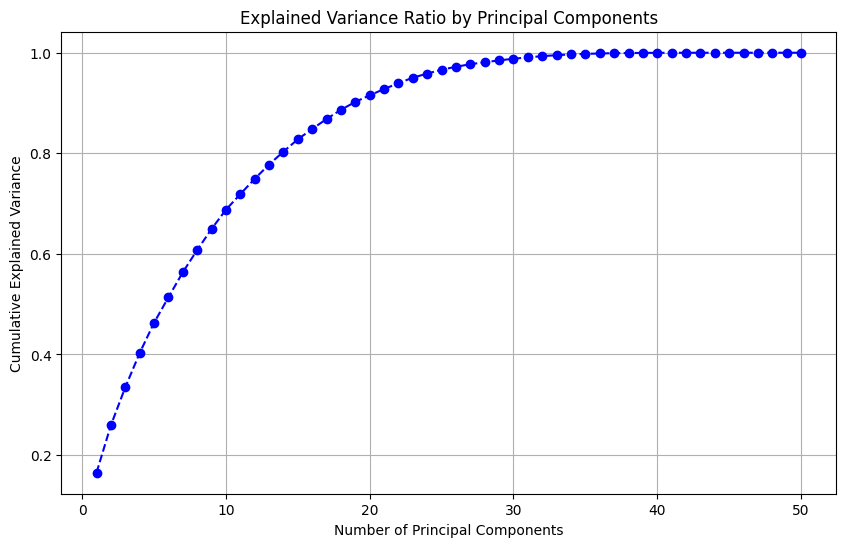

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def perform_pca_and_plot(X, n_components=None):
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Plot the explained variance ratio
    plt.figure(figsize=(10, 6))
    plt.plot(
        range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_.cumsum(), 
        marker='o', linestyle='--', color='b'
    )
    plt.title('Explained Variance Ratio by Principal Components')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()
    
    return X_pca, pca

# Example Usage
# Assuming your dataset is `final_dataset` and target column is 'target'
target_column = "ESG Score"  # Replace with your target column name
X = final_dataset.drop(columns=[target_column, 'Company', 'Risk Rating',
       'Industry Ranking', 'Global Ranking'])  # Exclude target and non-numerical identifier columns
y = final_dataset[target_column]

# Perform PCA and plot
X_pca, pca = perform_pca_and_plot(X)

<h1> Raw Model Results

In [9]:
variance_threshold = 0.999999

Applying PCA for 0.999999% explained variance...
Number of components selected for 99.9999% explained variance: 46
Training and evaluating models...
Training Linear Regression...


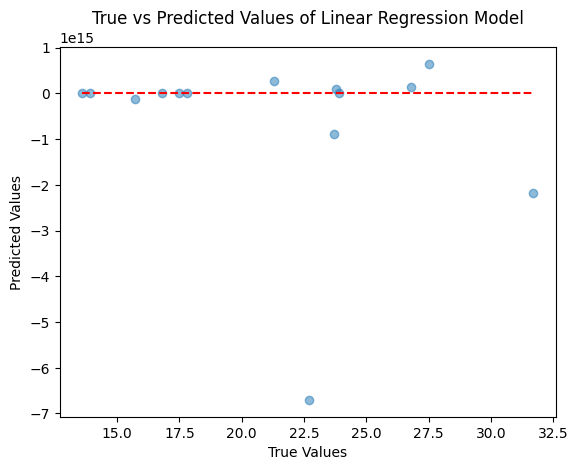

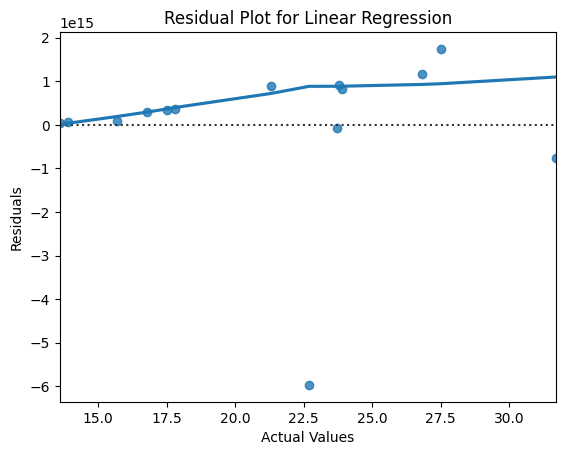

Training Lasso Regression...


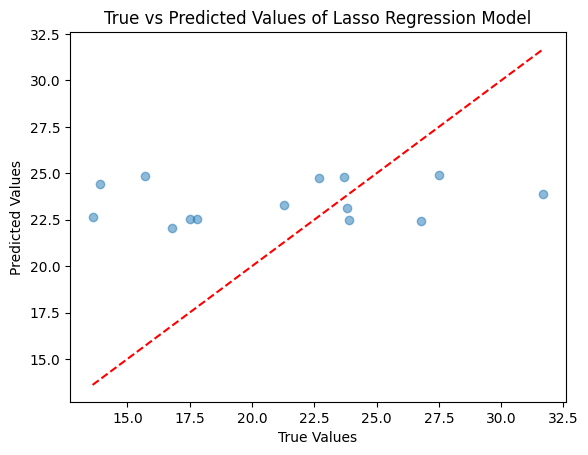

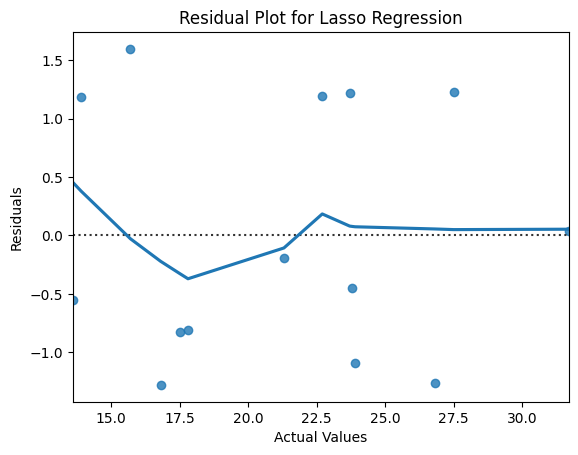

Training Ridge Regression...


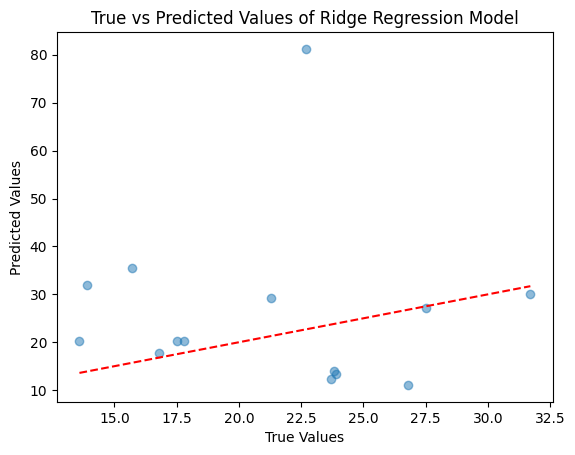

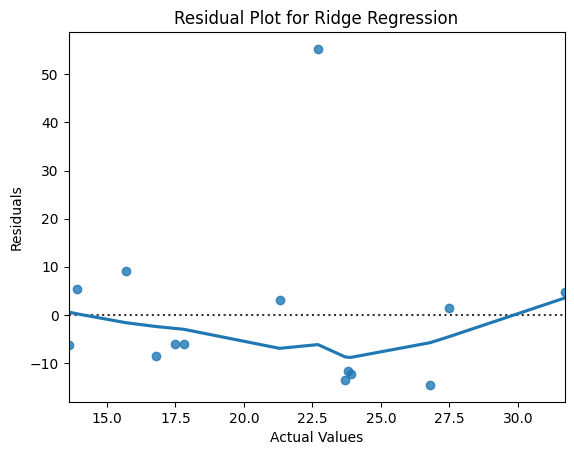

Training Random Forest...


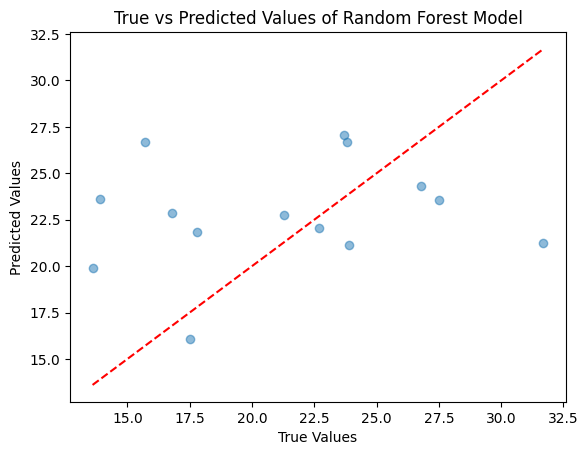

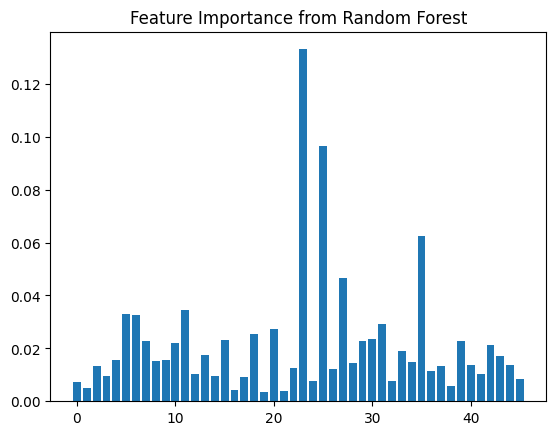

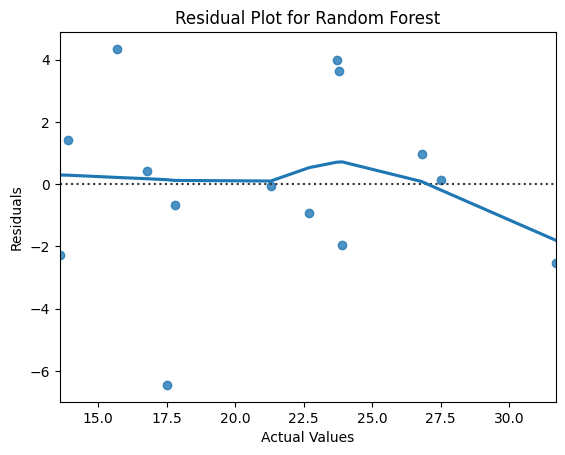

Training Gradient Boosting...


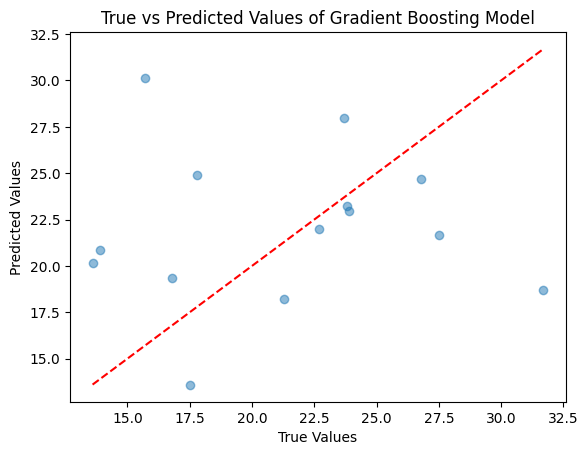

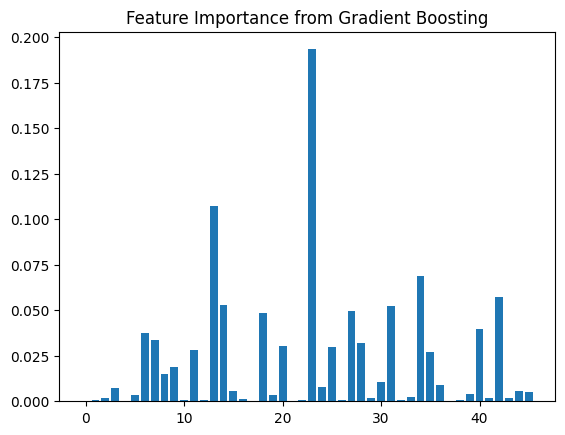

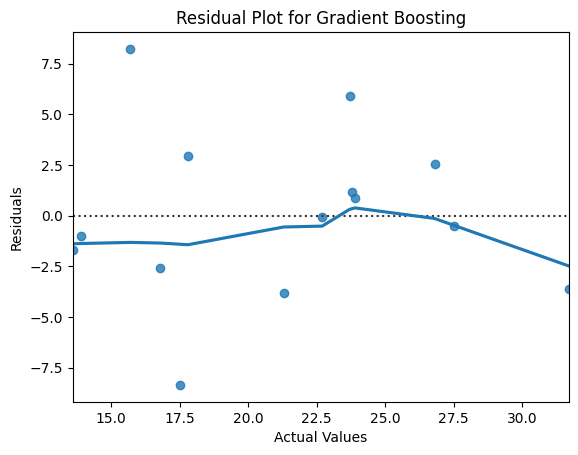

Training Support Vector Regressor (SVR)...


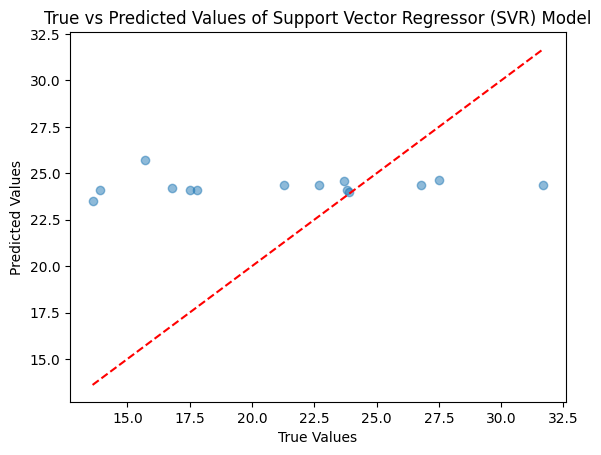

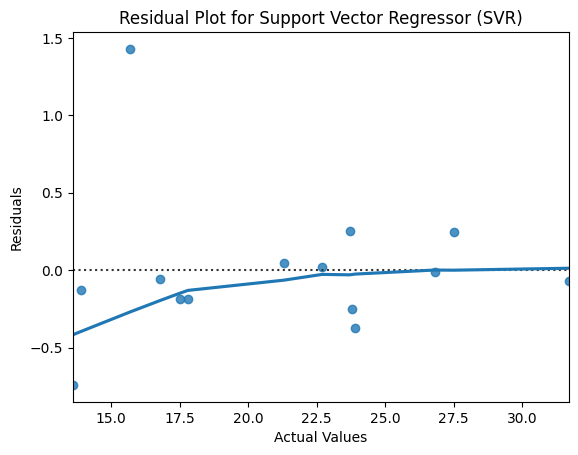

Training K-Nearest Neighbors (KNN)...


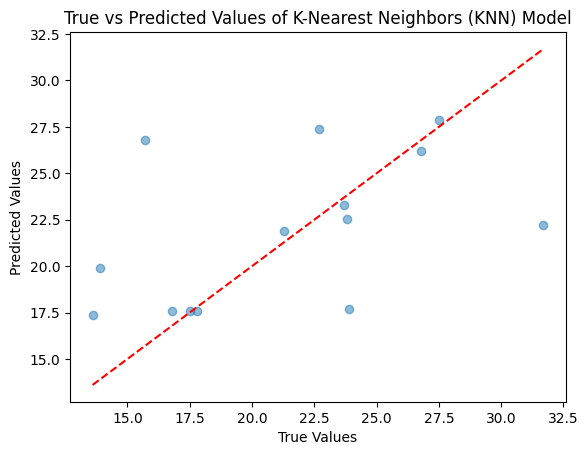

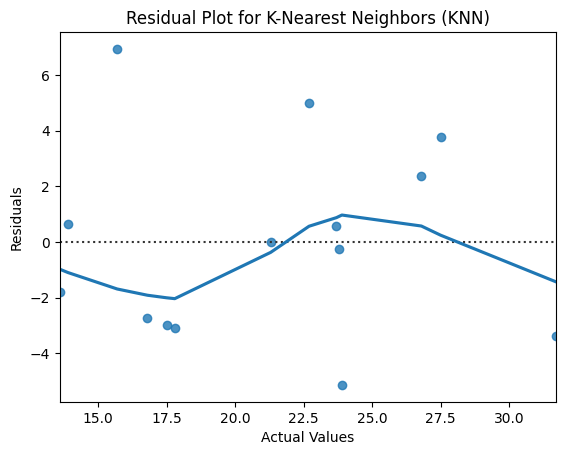


Model Evaluation Results:
                            Model           MSE           MAE      R² Score
0               Linear Regression  3.642867e+30  7.875619e+14 -1.308470e+29
1                Lasso Regression  3.215283e+01  4.692746e+00 -1.548873e-01
2                Ridge Regression  3.461689e+02  1.189000e+01 -1.143393e+01
3                   Random Forest  3.362640e+01  4.757395e+00 -2.078159e-01
4               Gradient Boosting  4.345058e+01  5.139094e+00 -5.606875e-01
5  Support Vector Regressor (SVR)  3.731118e+01  4.938834e+00 -3.401685e-01
6       K-Nearest Neighbors (KNN)  2.339677e+01  3.255714e+00  1.596187e-01


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve 90% explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train and Evaluate Models
def evaluate_models(X_train, X_test, y_train, y_test):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(alpha=1.0),  # Lasso regression with default alpha
        "Ridge Regression": Ridge(alpha=1.0),  # Ridge regression with default alpha
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(kernel='rbf'),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor(n_neighbors=5)
    }
    
    results = []
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title("True vs Predicted Values of {} Model".format(name))
        plt.show()
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot Feature Importances if applicable
        try:
            feature_importances = model.feature_importances_
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass
        
        # Residual Plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        results.append({
            "Model": name,
            "MSE": mse,
            "MAE": mae,
            "R² Score": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset
    
    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company', 'Risk Rating',
       'Industry Ranking', 'Global Ranking'])  # Exclude 'Hisse' and target column
    y = df["ESG Score"]

    # Apply PCA
    print(f"Applying PCA for {variance_threshold}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Train and evaluate models
    print("Training and evaluating models...")
    results = evaluate_models(X_train, X_test, y_train, y_test)

    # Display results
    print("\nModel Evaluation Results:")
    print(results)

if __name__ == "__main__":
    main()


<H1> Fine-Tune Added

Applying PCA for 0.999999% explained variance...
Number of components selected for 99.9999% explained variance: 46
Training and evaluating models with tuning...
Training and tuning Linear Regression...


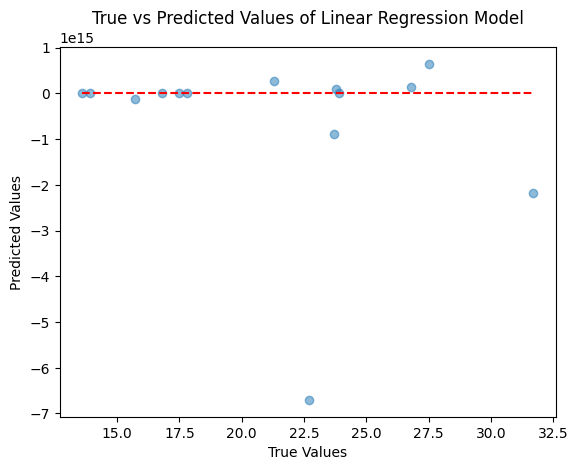

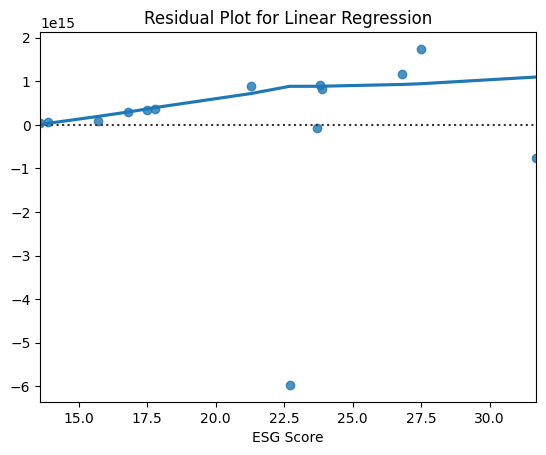

Training and tuning Lasso Regression...
Best params for Lasso Regression: {'alpha': 10}


/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.195e-01, tolerance: 2.212e-01
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.273e+00, tolerance: 2.111e-01
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

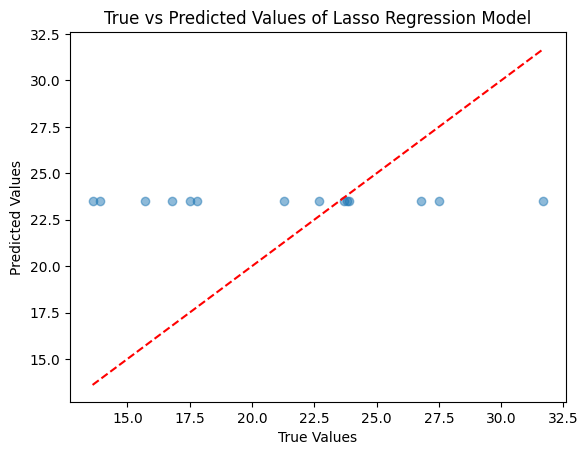

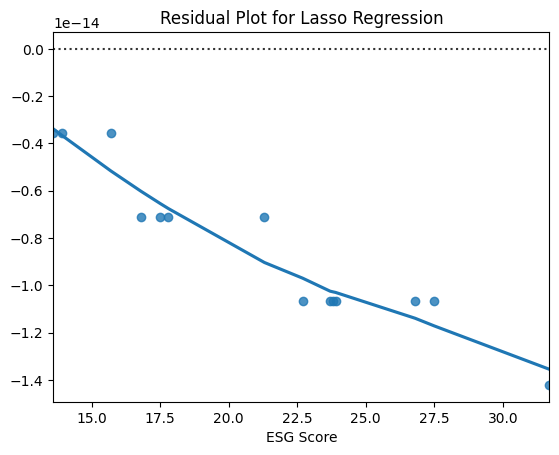

Training and tuning Ridge Regression...
Best params for Ridge Regression: {'alpha': 10}


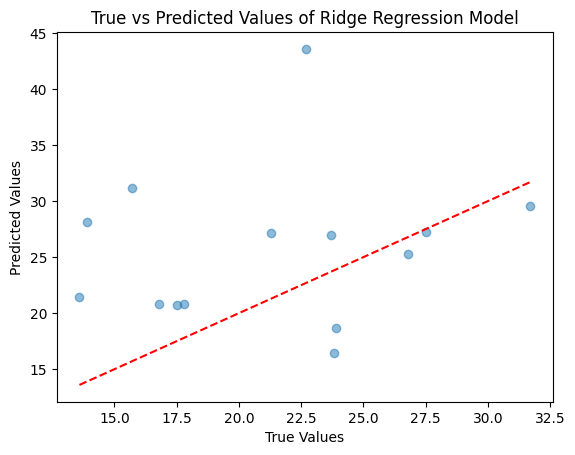

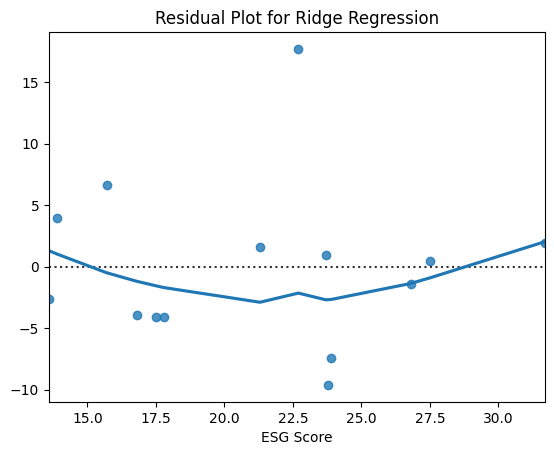

Training and tuning Random Forest...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}


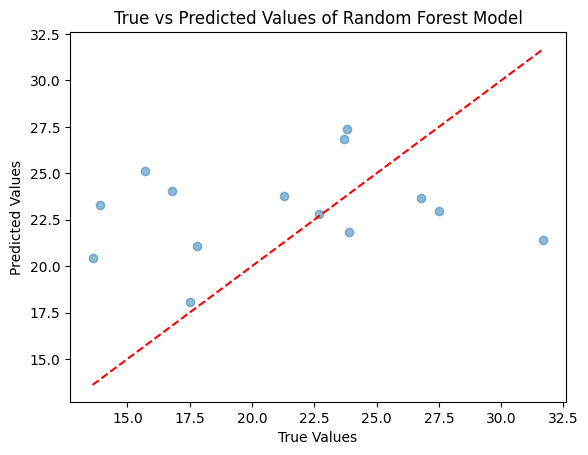

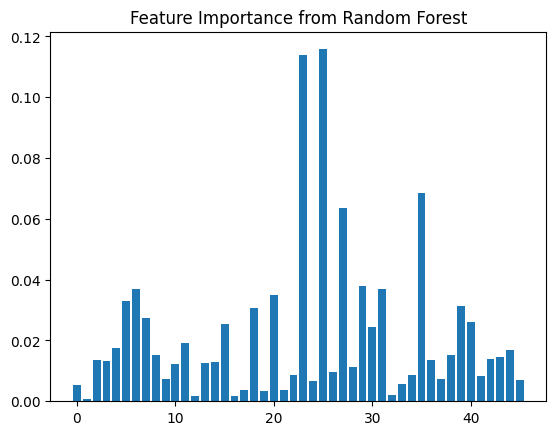

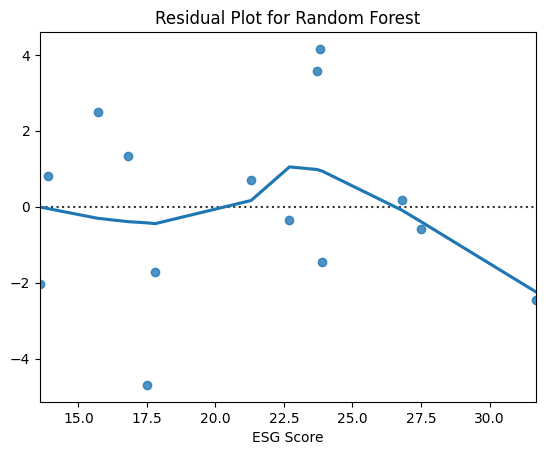

Training and tuning Gradient Boosting...
Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


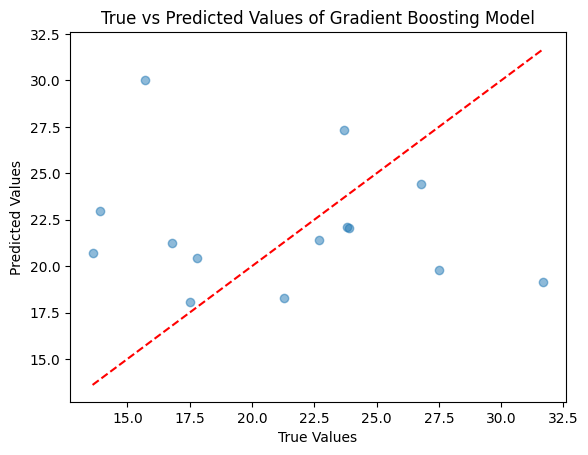

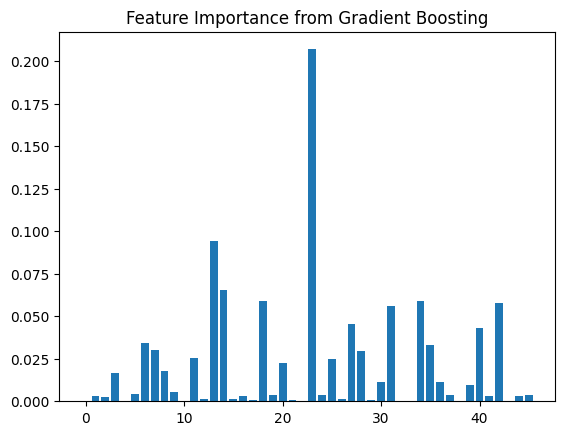

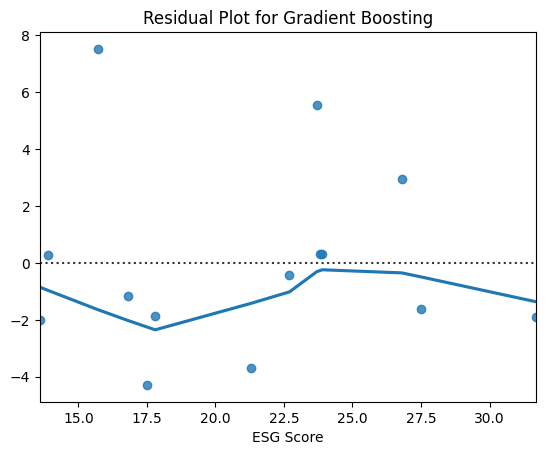

Training and tuning Support Vector Regressor (SVR)...


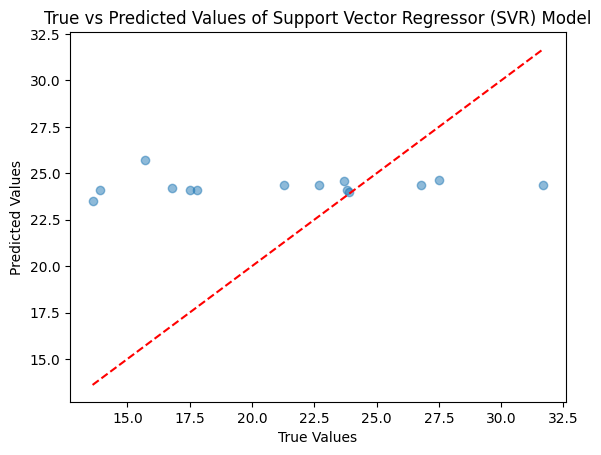

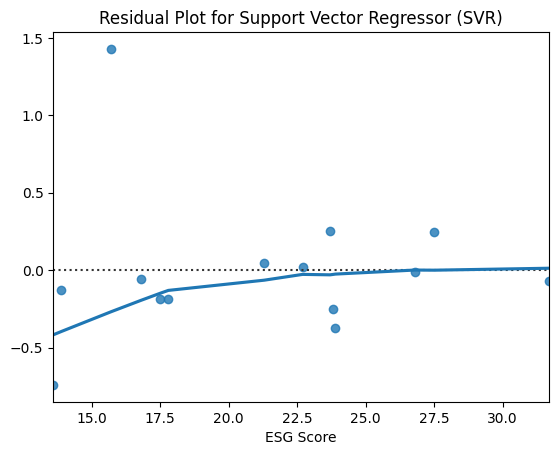

Training and tuning K-Nearest Neighbors (KNN)...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 10, 'weights': 'uniform'}


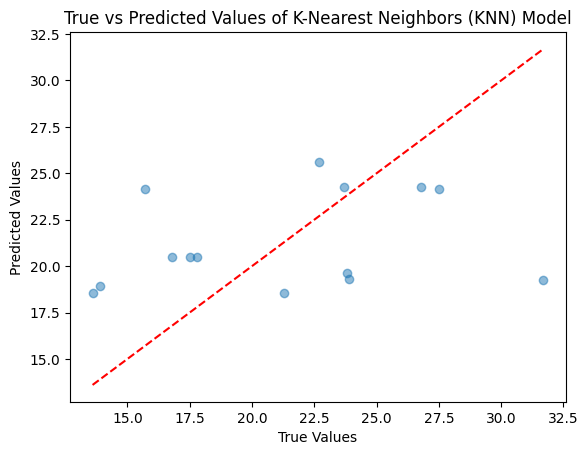

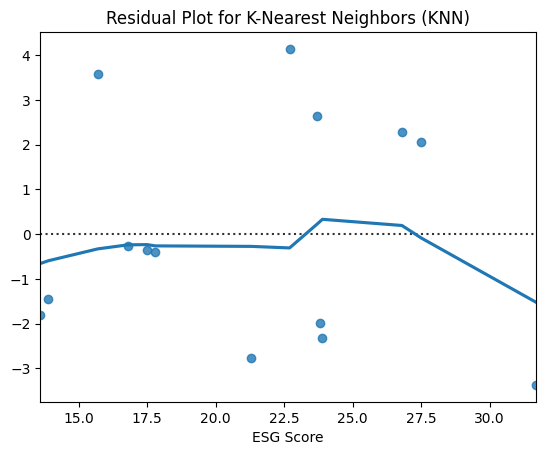


Model Evaluation Results:
                            Model           MSE           MAE      R² Score
0               Linear Regression  3.642867e+30  7.875619e+14 -1.308470e+29
1                Lasso Regression  3.318832e+01  4.650765e+00 -1.920808e-01
2                Ridge Regression  7.902523e+01  6.733808e+00 -1.838482e+00
3                   Random Forest  3.253642e+01  4.714939e+00 -1.686656e-01
4               Gradient Boosting  4.415892e+01  5.160595e+00 -5.861304e-01
5  Support Vector Regressor (SVR)  3.731118e+01  4.938834e+00 -3.401685e-01
6       K-Nearest Neighbors (KNN)  2.703394e+01  4.360000e+00  2.897634e-02


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold=0.90):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve 90% explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train, Evaluate, and Tune Models
def evaluate_and_tune_models(X_train, X_test, y_train, y_test):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Lasso Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Ridge Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []
    
    for name, model in models.items():
        print(f"Training and tuning {name}...")
        
        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=3, scoring='neg_mean_squared_error')
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title("True vs Predicted Values of {} Model".format(name))
        plt.show()
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot feature importance if available
        try:
            feature_importances = best_model.feature_importances_ 
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass
        
        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "MSE": mse,
            "MAE": mae,
            "R² Score": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():

    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset
    
    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company', 'Risk Rating',
       'Industry Ranking', 'Global Ranking'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    # Apply PCA
    print(f"Applying PCA for {variance_threshold}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Evaluate and tune models
    print("Training and evaluating models with tuning...")
    results = evaluate_and_tune_models(X_train, X_test, y_train, y_test)

    # Display results
    print("\nModel Evaluation Results:")
    print(results)

if __name__ == "__main__":
    main()


<h1> Cross-Validation Added

Applying PCA for 99.9999% explained variance...
Number of components selected for 99.9999% explained variance: 46
Training and evaluating models with 5-fold cross-validation...
Training and tuning Linear Regression with 5-fold cross-validation...


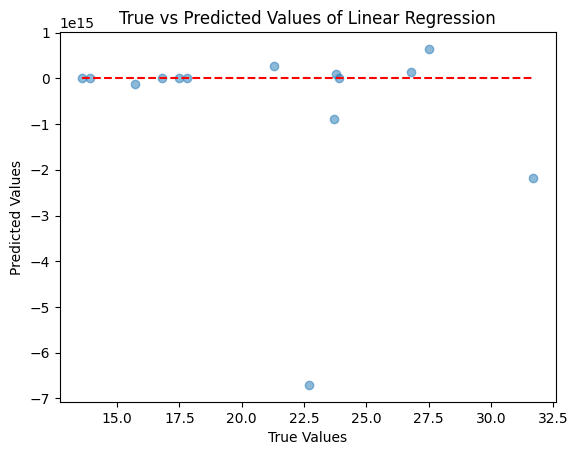

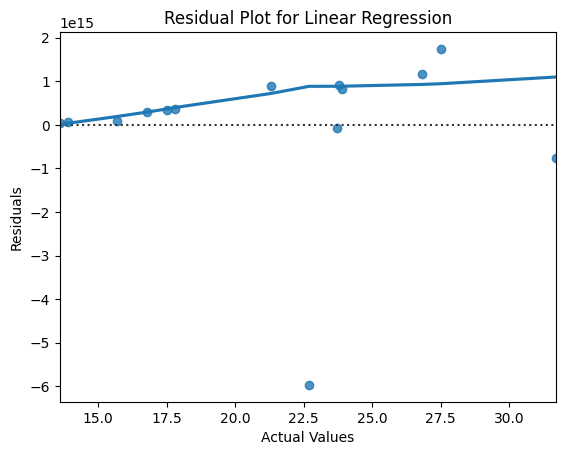

Training and tuning Lasso Regression with 5-fold cross-validation...
Best params for Lasso Regression: {'alpha': 10}


/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.119e+00, tolerance: 2.348e-01
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.191e+00, tolerance: 2.551e-01
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

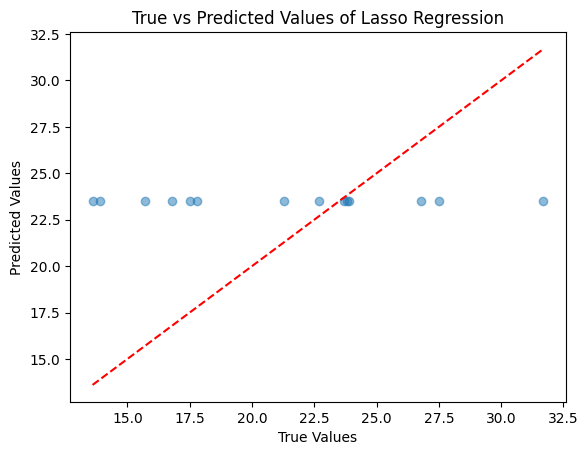

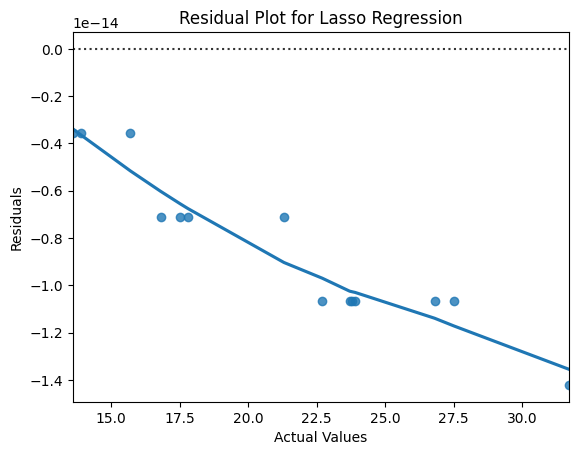

Training and tuning Ridge Regression with 5-fold cross-validation...
Best params for Ridge Regression: {'alpha': 10}


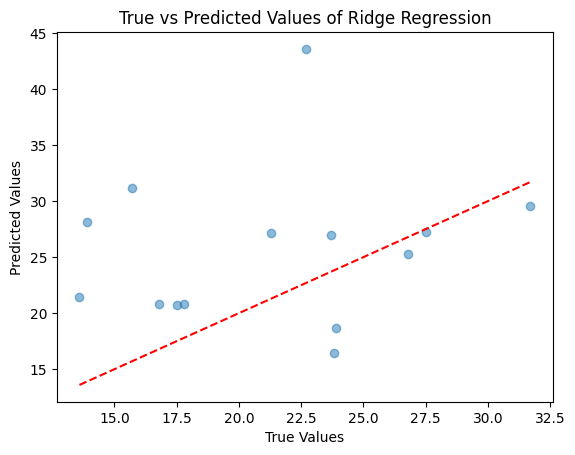

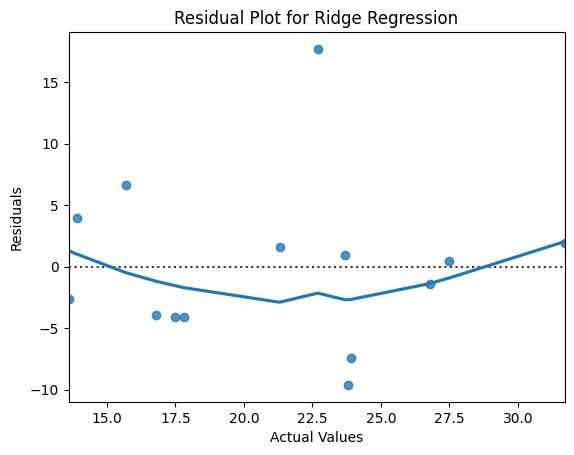

Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


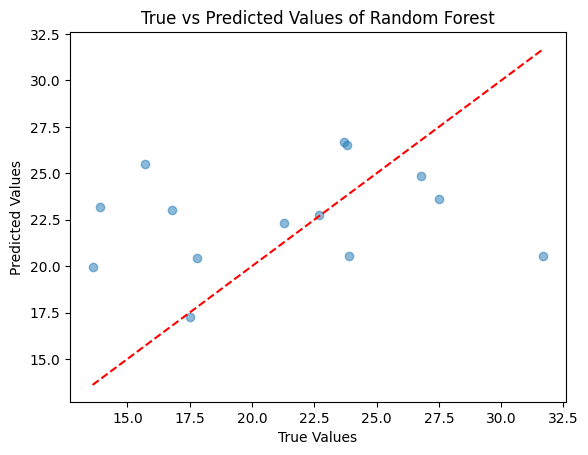

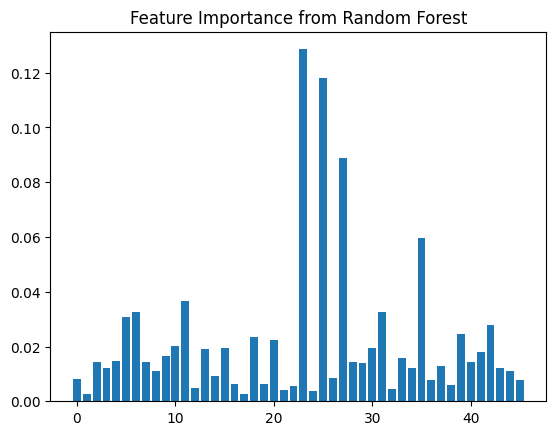

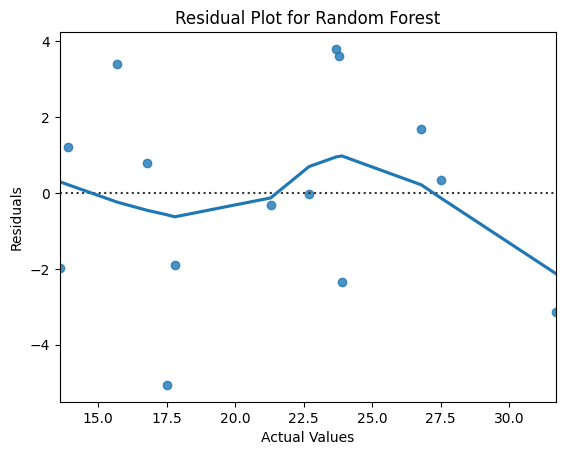

Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


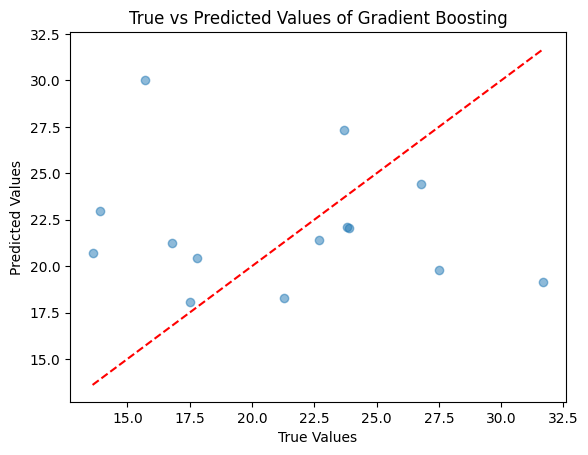

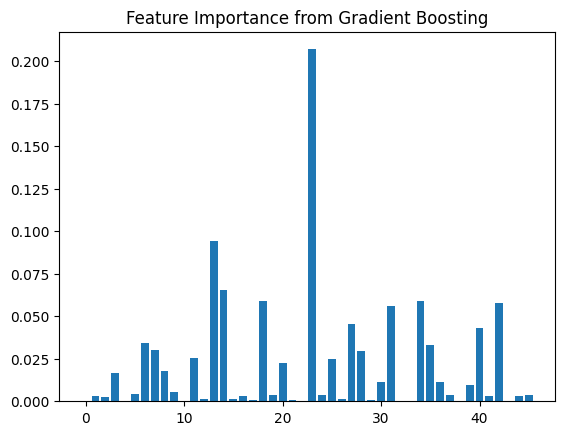

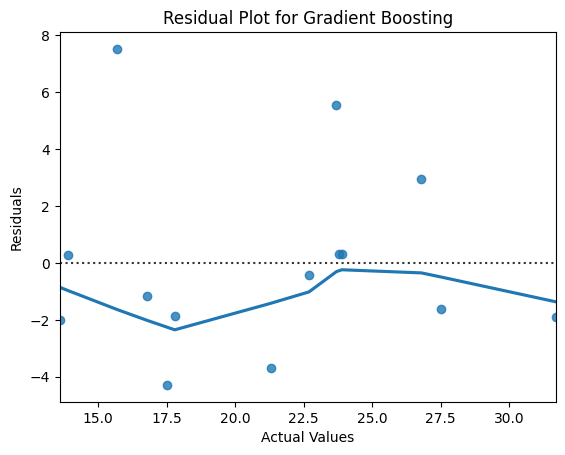

Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...


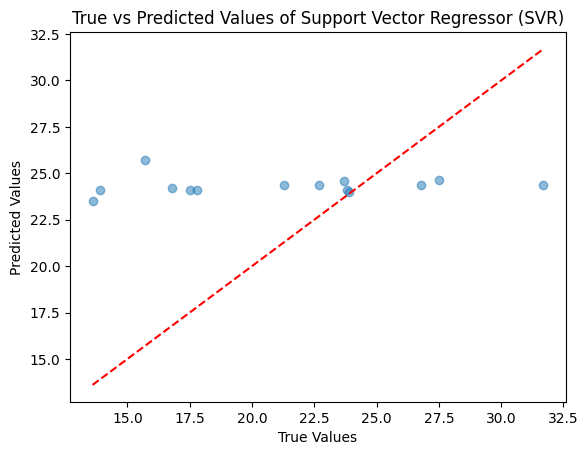

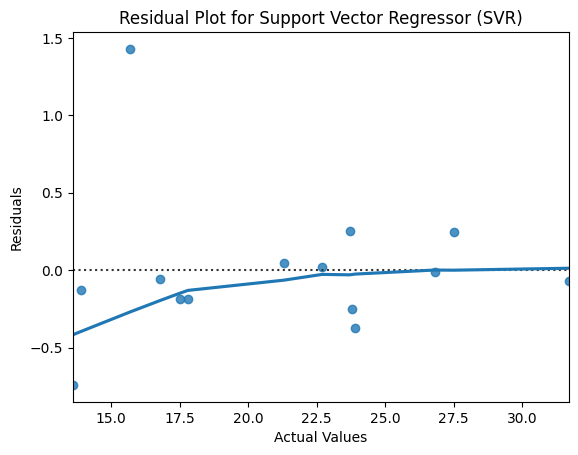

Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 10, 'weights': 'distance'}


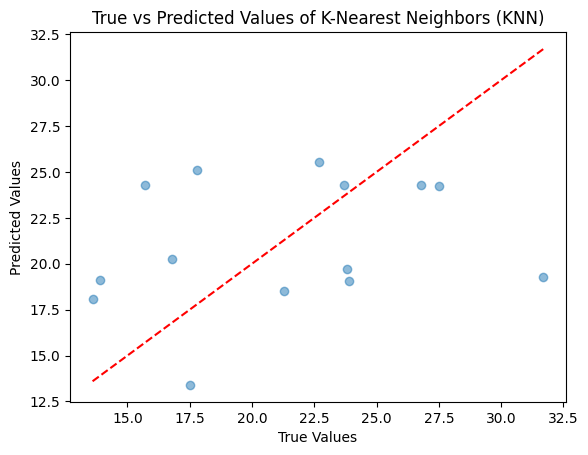

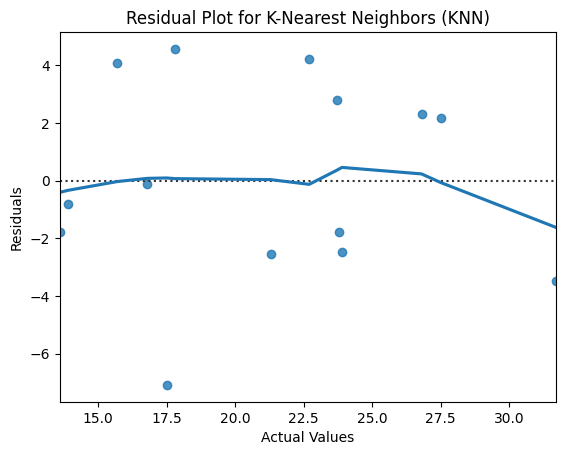


Model Evaluation Results with Cross-Validation:
                            Model     Avg CV MSE      Test MSE      Test MAE  \
0               Linear Regression  147582.356683  3.642867e+30  7.875619e+14   
1                Lasso Regression      56.648757  3.318832e+01  4.650765e+00   
2                Ridge Regression      76.712084  7.902523e+01  6.733808e+00   
3                   Random Forest      53.223166  3.148707e+01  4.408047e+00   
4               Gradient Boosting      71.511026  4.415892e+01  5.160595e+00   
5  Support Vector Regressor (SVR)      54.951556  3.731118e+01  4.938834e+00   
6       K-Nearest Neighbors (KNN)      66.736369  3.074297e+01  4.743573e+00   

        Test R²  
0 -1.308470e+29  
1 -1.920808e-01  
2 -1.838482e+00  
3 -1.309742e-01  
4 -5.861304e-01  
5 -3.401685e-01  
6 -1.042472e-01  


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve the specified explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=5):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Lasso Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Ridge Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Cross-validation scores
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
        avg_cv_mse = -np.mean(cv_scores)  # Convert to positive MSE

        # Make predictions on test set
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title(f"True vs Predicted Values of {name}")
        plt.show()

        # Calculate test set metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot feature importance if available
        try:
            feature_importances = best_model.feature_importances_
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass

        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "Avg CV MSE": avg_cv_mse,
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R²": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company', 'Risk Rating',
       'Industry Ranking', 'Global Ranking'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    print(f"Applying PCA for {variance_threshold * 100}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Evaluate and tune models with cross-validation
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nModel Evaluation Results with Cross-Validation:")
    print(results)

if __name__ == "__main__":
    main()


<h1> Train-Test Accuracy Plots Added

Applying PCA for 99.9999% explained variance...
Number of components selected for 99.9999% explained variance: 49
Training and evaluating models with 5-fold cross-validation...
Training and tuning Linear Regression with 5-fold cross-validation...
Training and tuning Lasso Regression with 5-fold cross-validation...


Best params for Lasso Regression: {'alpha': 0.01}
Training and tuning Ridge Regression with 5-fold cross-validation...
Best params for Ridge Regression: {'alpha': 1.0}
Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...
Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 3, 'weights': 'distance'}


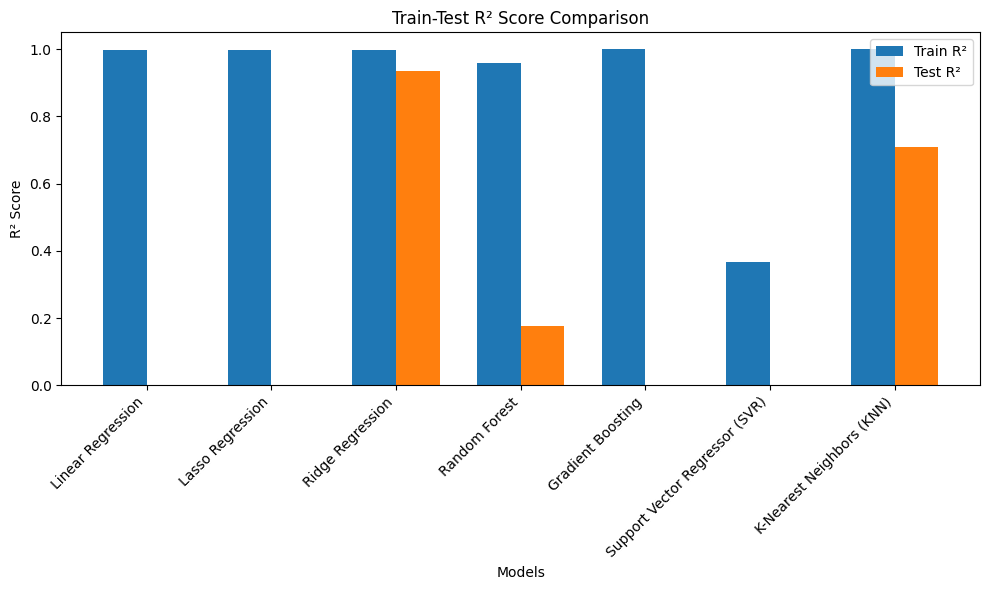


Train-Test R² Score Comparison:
                            Model  Train R²       Test R²
0               Linear Regression  0.998617 -2.027673e+25
1                Lasso Regression  0.997531 -3.511954e-01
2                Ridge Regression  0.997075  9.339982e-01
3                   Random Forest  0.957775  1.750022e-01
4               Gradient Boosting  1.000000 -5.395844e-02
5  Support Vector Regressor (SVR)  0.366067 -9.436462e-03
6       K-Nearest Neighbors (KNN)  1.000000  7.077326e-01


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Preprocess Data and Apply PCA
def preprocess_and_apply_pca(X, target, variance_threshold):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to achieve the specified explained variance
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    # Print explained variance ratio
    print(f"Number of components selected for {variance_threshold * 100}% explained variance: {pca.n_components_}")
    
    return X_pca, target, pca

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_compare_models(X_train, y_train, X_test, y_test, cv_folds=5):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Lasso Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Ridge Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {"C": [1, 10, 100], "kernel": ["linear", "rbf"], "gamma": ["scale", "auto"]},
        "K-Nearest Neighbors (KNN)": {"n_neighbors": [3, 5, 10], "weights": ["uniform", "distance"]}
    }
    
    train_r2_scores = []
    test_r2_scores = []
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Calculate train and test \( R^2 \) scores
        train_r2 = best_model.score(X_train, y_train)
        test_r2 = best_model.score(X_test, y_test)

        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)

        # Store results
        results.append({"Model": name, "Train R²": train_r2, "Test R²": test_r2})

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    # Plot train and test \( R^2 \) scores
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    indices = np.arange(len(models))

    # Make negative r^2 values 0
    train_r2_scores = np.maximum(train_r2_scores, 0)
    test_r2_scores = np.maximum(test_r2_scores, 0)

    plt.bar(indices, train_r2_scores, bar_width, label='Train R²')
    plt.bar(indices + bar_width, test_r2_scores, bar_width, label='Test R²')

    plt.xlabel('Models')
    plt.ylabel('R² Score')
    plt.title('Train-Test R² Score Comparison')
    plt.xticks(indices + bar_width / 2, models.keys(), rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["Company", 'ESG Score'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    print(f"Applying PCA for {variance_threshold * 100}% explained variance...")
    X_pca, y, pca = preprocess_and_apply_pca(X, y, variance_threshold)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Evaluate and compare models
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_compare_models(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nTrain-Test R² Score Comparison:")
    print(results)

if __name__ == "__main__":
    main()


<h1> LLE, UMAP, ISOMAP REDUCTION TECHNİQUES IMPLEMENTED

Applying Lle for dimensionality reduction...
Lle reduced data to 50 components.
Training and evaluating models with 5-fold cross-validation...
Training and tuning Linear Regression with 5-fold cross-validation...


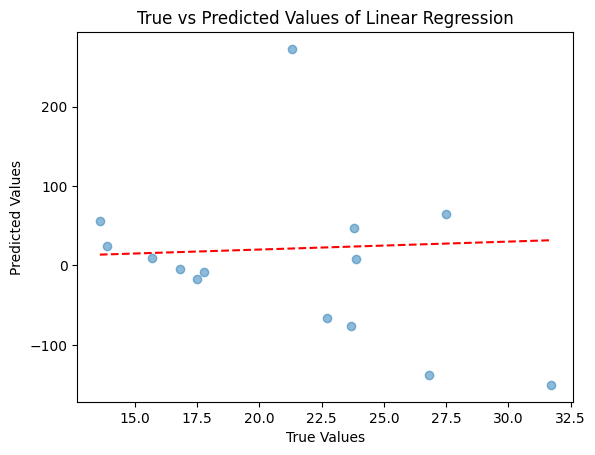

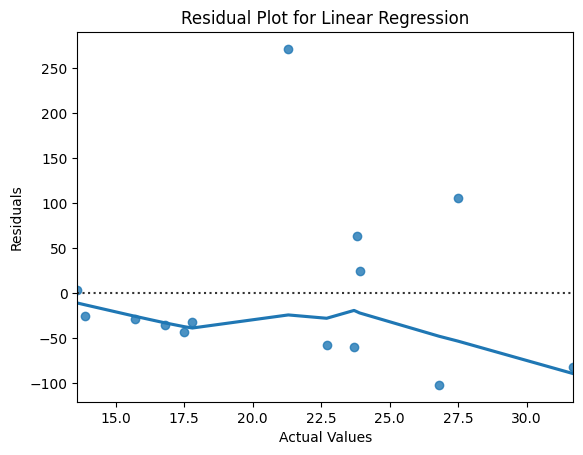

Training and tuning Lasso Regression with 5-fold cross-validation...
Best params for Lasso Regression: {'alpha': 1.0}


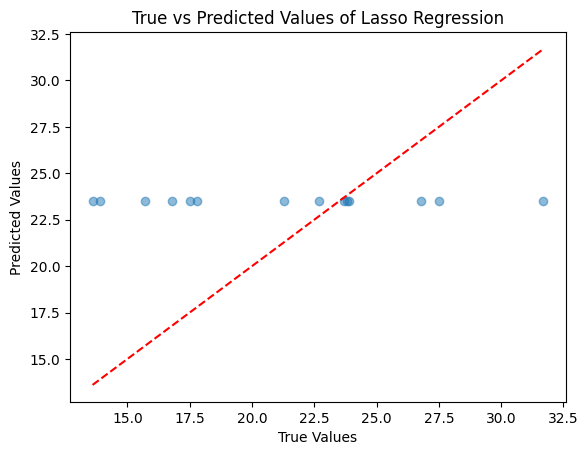

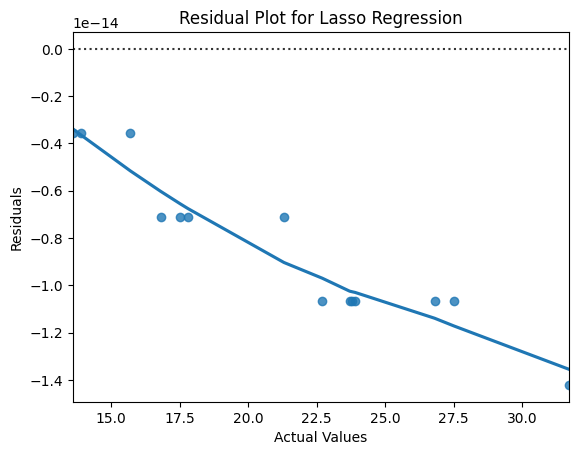

Training and tuning Ridge Regression with 5-fold cross-validation...
Best params for Ridge Regression: {'alpha': 10}


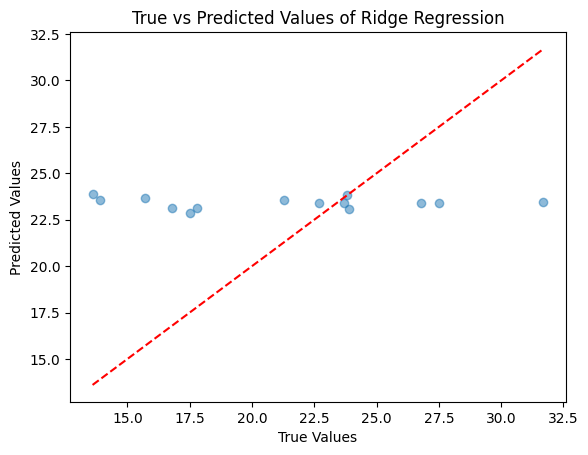

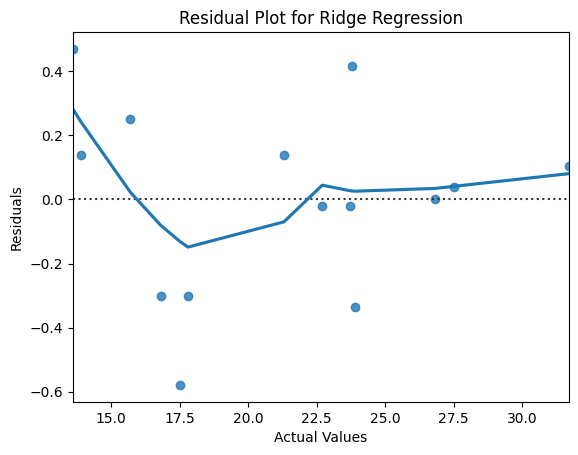

Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


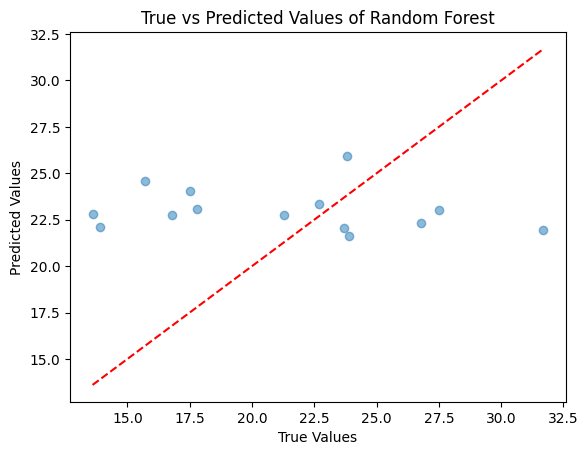

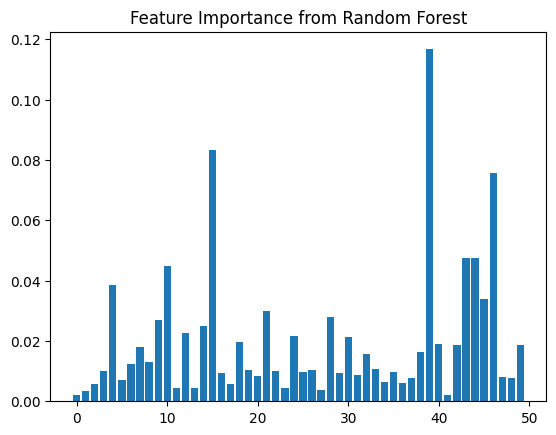

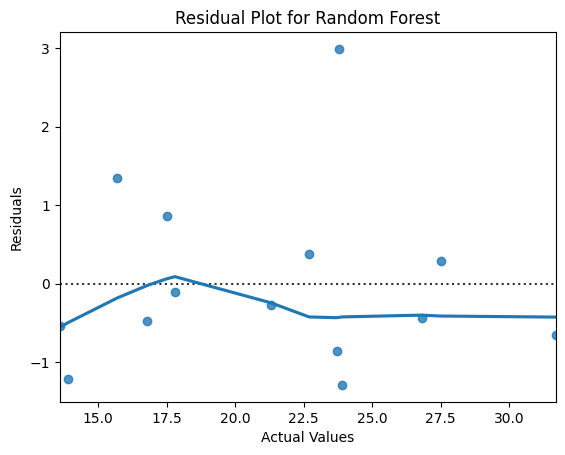

Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


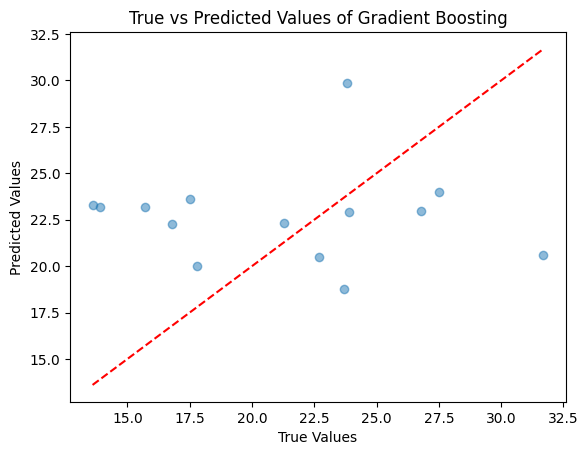

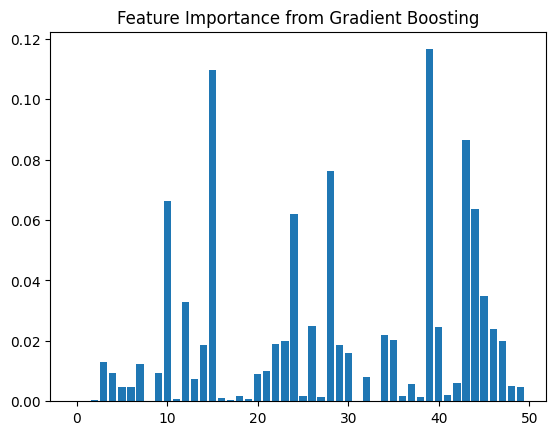

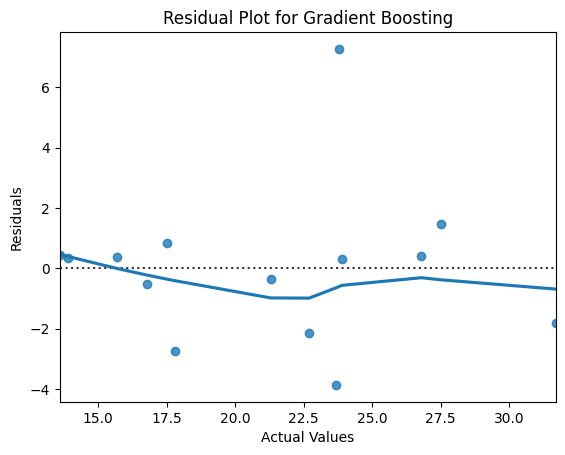

Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...


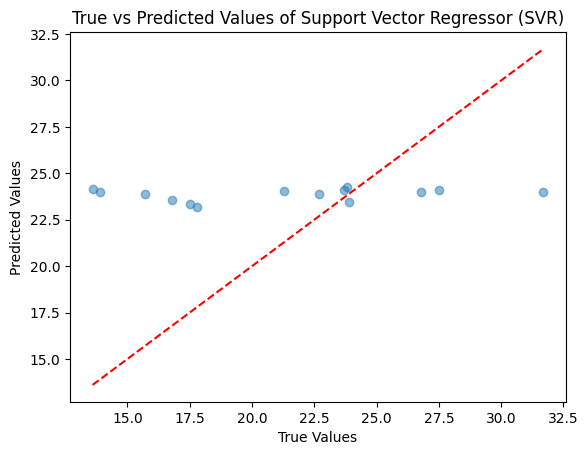

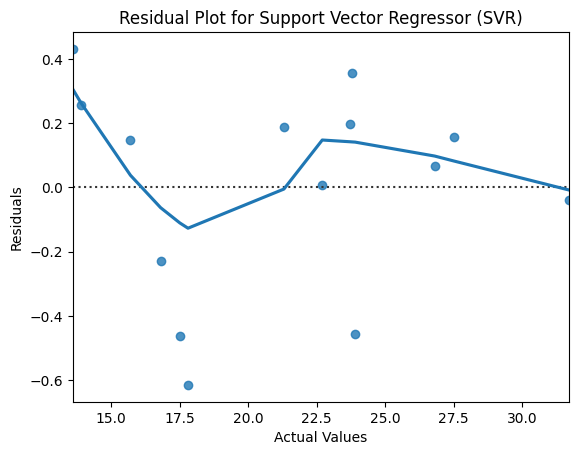

Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 10, 'weights': 'uniform'}


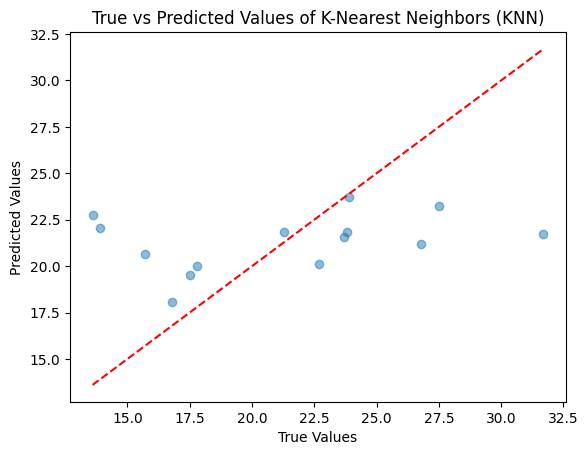

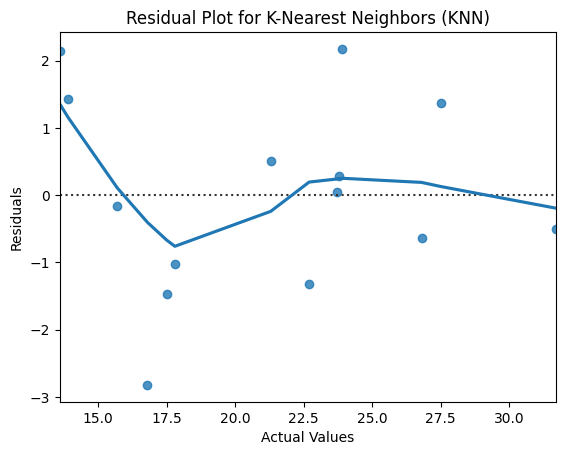


Model Evaluation Results with Cross-Validation:
                            Model    Avg CV MSE      Test MSE   Test MAE  \
0               Linear Regression  11187.542417  10547.647188  71.623495   
1                Lasso Regression     56.648757     33.188320   4.650765   
2                Ridge Regression     57.699301     32.993957   4.622723   
3                   Random Forest     60.835283     34.780024   5.059421   
4               Gradient Boosting     72.551501     37.655912   5.283087   
5  Support Vector Regressor (SVR)     57.507817     34.075591   4.707316   
6       K-Nearest Neighbors (KNN)     62.886940     24.990636   3.925000   

      Test R²  
0 -377.857612  
1   -0.192081  
2   -0.185100  
3   -0.249253  
4   -0.352551  
5   -0.223950  
6    0.102369  


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding

# Step 1: Preprocess Data and Apply Dimensionality Reduction
def preprocess_and_apply_reduction(X, target, method='umap', n_components=2):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply different dimensionality reduction methods based on 'method'
    if method == 'umap':
        import umap
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == 'isomap':
        reducer = Isomap(n_components=n_components)
    elif method == 'lle':
        reducer = LocallyLinearEmbedding(n_components=n_components)

    # Apply dimensionality reduction
    X_reduced = reducer.fit_transform(X_scaled)

    print(f"{method.capitalize()} reduced data to {n_components} components.")
    
    return X_reduced, target, reducer

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=5):
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    param_grids = {
        "Lasso Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Ridge Regression": {"alpha": [0.01, 0.1, 1.0, 10]},
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Cross-validation scores
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
        avg_cv_mse = -np.mean(cv_scores)  # Convert to positive MSE

        # Make predictions on test set
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title(f"True vs Predicted Values of {name}")
        plt.show()

        # Calculate test set metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot feature importance if available
        try:
            feature_importances = best_model.feature_importances_
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass

        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "Avg CV MSE": avg_cv_mse,
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R²": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company', 'Risk Rating',
       'Industry Ranking', 'Global Ranking'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    # Select dimensionality reduction method: 'umap', 'isomap', or 'lle'
    method = 'lle'  # Change this to 'lle' or 'umap' as needed

    print(f"Applying {method.capitalize()} for dimensionality reduction...")
    X_reduced, y, reducer = preprocess_and_apply_reduction(X, y, method=method, n_components=50)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

    # Evaluate and tune models with cross-validation
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nModel Evaluation Results with Cross-Validation:")
    print(results)

if __name__ == "__main__":
    main()